--- 1. MATRIZ DE CORRELACIÓN ---


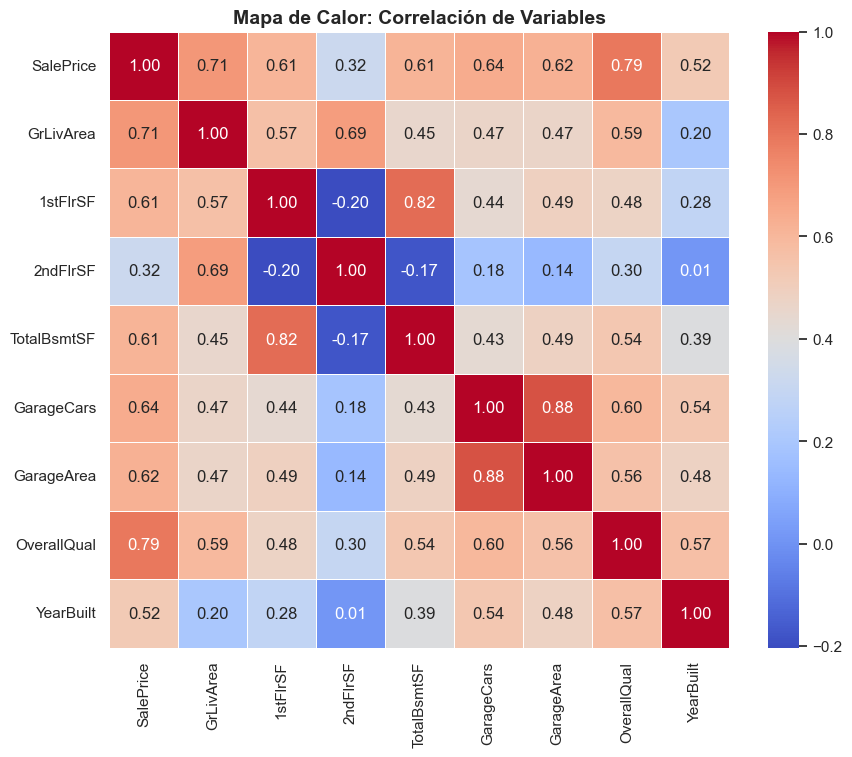


--- 2. MODELO DE REGRESIÓN OLS (INICIAL) ---
                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.770
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     607.3
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:11:21   Log-Likelihood:                -17471.
No. Observations:                1460   AIC:                         3.496e+04
Df Residuals:                    1451   BIC:                         3.501e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
cons

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, r2_score

# Configuración visual
sns.set_theme(style="whitegrid", palette="muted")

# 1. CARGA DE DATOS
ruta_csv = r"C:\Users\Yamil\OneDrive\Escritorio\Escritorio\Yamil\EBAC (CIENCIA DE DATOS)\Bloque 6 Estadística\MOD 3 Concep Adv Estadis\Práctica\House Pricing.csv"
df = pd.read_csv(ruta_csv)

# Seleccionamos variables numéricas estratégicas para forzar multicolinealidad y luego limpiarla
columnas = ['SalePrice', 'GrLivArea', '1stFlrSF', '2ndFlrSF', 'TotalBsmtSF', 'GarageCars', 'GarageArea', 'OverallQual', 'YearBuilt']
df_model = df[columnas].dropna()

# ==============================================================================
# REQUISITO 1: CORRELACIÓN Y HEATMAP
# ==============================================================================
print("--- 1. MATRIZ DE CORRELACIÓN ---")
plt.figure(figsize=(10, 8))
correlacion = df_model.corr()
# Heatmap destacando las relaciones
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor: Correlación de Variables', fontsize=14, fontweight='bold')
plt.show()

# ==============================================================================
# REQUISITO 2 y 3: MODELO OLS INICIAL Y REPORTE (.summary)
# ==============================================================================
print("\n--- 2. MODELO DE REGRESIÓN OLS (INICIAL) ---")
# Definimos variable dependiente (Y) e independientes (X)
X_inicial = df_model.drop(columns=['SalePrice'])
Y = df_model['SalePrice']

# Agregamos la constante (intercepto) requerida por statsmodels
X_inicial_const = sm.add_constant(X_inicial)

# Entrenamos el modelo
modelo_inicial = sm.OLS(Y, X_inicial_const).fit()
print(modelo_inicial.summary())

# ==============================================================================
# REQUISITO 4: ANÁLISIS DE MULTICOLINEALIDAD (VIF)
# ==============================================================================
print("\n--- 3. ANÁLISIS DE MULTICOLINEALIDAD (VIF) ---")
# Calculamos el VIF para cada variable explicativa
vif_data = pd.DataFrame()
vif_data["Variable"] = X_inicial_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_inicial_const.values, i) for i in range(X_inicial_const.shape[1])]
print(vif_data)
print("\n*Nota: Valores VIF > 5 o 10 indican alta multicolinealidad.")

# ==============================================================================
# REQUISITO 5: MODELO FINAL AJUSTADO
# ==============================================================================
print("\n--- 4. MODELO FINAL AJUSTADO ---")
# Eliminamos 1stFlrSF, 2ndFlrSF (colineales con GrLivArea) y GarageCars (colineal con GarageArea)
X_final = df_model[['GrLivArea', 'TotalBsmtSF', 'GarageArea', 'OverallQual', 'YearBuilt']]
X_final_const = sm.add_constant(X_final)

# Entrenamos el nuevo modelo limpio
modelo_final = sm.OLS(Y, X_final_const).fit()
print(modelo_final.summary())

# ==============================================================================
# REQUISITO 6: DESEMPEÑO DEL MODELO (MSE y R2)
# ==============================================================================
print("\n--- 5. MÉTRICAS DE DESEMPEÑO DEL MODELO FINAL ---")
# Hacemos predicciones con el modelo ajustado
Y_pred = modelo_final.predict(X_final_const)

# Calculamos MSE y R2
mse = mean_squared_error(Y, Y_pred)
r2 = r2_score(Y, Y_pred)

print(f"Error Cuadrático Medio (MSE): {mse:,.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")